<a href="https://colab.research.google.com/github/EduardoAve/Natural-language-processing/blob/main/sesion_4/sentiment_classification_tweets_es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de Sentimientos en Reseñas en Español con HuggingFace

**Actividad:** Versión propia del notebook `1-text-classification-with-hf`  
**Dataset:** `SetFit/amazon_reviews_multi_es` (reseñas de Amazon en español)  
**Tarea:** Clasificación de sentimiento en 3 clases: Negativo (1-2 estrelas), Neutral (3 estrellas), Positivo (4-5 estrellas)

---

Este notebook utiliza el mismo dataset base que el segundo trabajo (LSTM sobre Amazon Reviews), aunque con una diferencia importante: en esta ocasión **las 5 calificaciones de estrellas se colapsan a 3 clases de sentimiento** (Negativo / Neutral / Positivo). Esta decisión es deliberada — la tarea de 5 clases con reseñas de Amazon resultó en un accuracy del ~48% con LSTM, lo que en parte se debe a la dificultad de distinguir entre calificaciones adyacentes (2 vs. 3 estrellas, 4 vs. 5 estrellas). Al reducir a 3 clases se elimina parte de esa ambigüedad semántica y el problema se vuelve más tratable para comparar entre arquitecturas.

Adicionalmente, el uso de este dataset se explica también por razones prácticas: se agotaron los créditos de GPU disponibles en colab, por lo que se optó por un dataset ya conocido que permitiera correr los experimentos de manera eficiente.

| Característica | Noticias (original) | Amazon Reviews (este notebook) |
|---|---|---|
| Longitud promedio | ~500 palabras | Variable (desde 5 hasta cientos de palabras) |
| Lenguaje | Formal, objetivo | Informal, subjetivo, emocional |
| Número de clases | 12 (tópico) | 3 (sentimiento) |
| Etiquetas | Asignadas por redactores | Derivadas de estrellas (1-5) |
| Ambigüedad | Baja | Alta (3 estrellas = ?) |

La clasificación de sentimiento es intrínsecamente más subjetiva que la clasificación de tópicos. Una reseña de 3 estrellas puede contener tanto comentarios positivos como negativos, lo que representa un reto diferente al notebook guía.

## 0. Configuración del Entorno

In [1]:
# Verificamos si estamos en Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("✅ Ejecutando en Google Colab")
except ImportError:
    IN_COLAB = False
    print("💻 Ejecutando en entorno local")

✅ Ejecutando en Google Colab


In [2]:
if IN_COLAB:
    !pip install -q transformers datasets evaluate torchinfo wordcloud seaborn scikit-learn accelerate
    print("✅ Dependencias instaladas (Colab)")
else:
    import subprocess, sys
    pkgs = ["transformers", "datasets", "evaluate", "wordcloud", "seaborn", "scikit-learn", "accelerate"]
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=True)
    print("✅ Dependencias instaladas (local)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
✅ Dependencias instaladas (Colab)


In [3]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
import evaluate
from sklearn.metrics import confusion_matrix

# Configuración del dispositivo
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"🚀 GPU disponible: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("🍎 Apple Silicon MPS disponible")
else:
    DEVICE = torch.device("cpu")
    print("⚠️ Usando CPU — el entrenamiento será lento")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

🚀 GPU disponible: Tesla T4


## 1. Carga y Exploración del Dataset (EDA)

El dataset `SetFit/amazon_reviews_multi_es` es una versión en formato Parquet del clásico Amazon Reviews Multi, compatible con versiones modernas de la librería `datasets`. Contiene 200,000 reseñas de entrenamiento en español con calificaciones de 1 a 5 estrellas (representadas como labels 0-4). Las estrellas se mapean a tres clases de sentimiento:

- Labels 0-1 (1-2 estrellas) → **Negativo**
- Label 2 (3 estrellas) → **Neutral**
- Labels 3-4 (4-5 estrellas) → **Positivo**

In [4]:
# Carga del dataset — reseñas de Amazon en español
# SetFit/amazon_reviews_multi_es es una versión en Parquet, compatible con
# versiones modernas de la librería datasets (sin scripts .py heredados).
raw_dataset = load_dataset("SetFit/amazon_reviews_multi_es")
print(raw_dataset)

README.md:   0%|          | 0.00/310 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/43.8M [00:00<?, ?B/s]

validation.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/200000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 200000
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text'],
        num_rows: 5000
    })
})


In [5]:
# El dataset tiene labels 0-4 (equivalente a estrellas 1-5, indexadas desde 0).
# Las mapeamos a 3 clases de sentimiento:
#   0-1 (1-2 estrellas) → Negativo
#   2   (3 estrellas)   → Neutral
#   3-4 (4-5 estrellas) → Positivo

def stars_to_sentiment(example):
    label_orig = example["label"]  # 0-4
    if label_orig <= 1:
        example["sentiment"] = 0   # Negativo
    elif label_orig == 2:
        example["sentiment"] = 1   # Neutral
    else:
        example["sentiment"] = 2   # Positivo
    example["stars"] = label_orig + 1  # Guardamos estrellas 1-5 para la EDA
    return example

dataset = raw_dataset.map(stars_to_sentiment)
dataset = dataset.select_columns(["text", "sentiment", "stars"])
dataset = dataset.rename_column("sentiment", "label")

# Subconjunto de entrenamiento:
#   Colab GPU → 20,000 ejemplos (~7 min por enfoque)
#   Local M2  →  5,000 ejemplos (~5 min por enfoque)
TRAIN_SIZE = 20_000 if IN_COLAB else 5_000
dataset["train"] = dataset["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
print(f"{'🚀 Colab' if IN_COLAB else '💻 Local'}: usando {TRAIN_SIZE:,} ejemplos de entrenamiento")

# Mapeo de etiquetas
LABEL_NAMES = {0: "Negativo", 1: "Neutral", 2: "Positivo"}
NUM_LABELS = len(LABEL_NAMES)
id2label = LABEL_NAMES
label2id = {v: k for k, v in id2label.items()}

# Vista previa
df_train = pd.DataFrame(dataset["train"])
df_train["label_name"] = df_train["label"].map(LABEL_NAMES)

print(f"\nTamaño del conjunto de entrenamiento: {len(df_train):,} reseñas")
print(f"\nEjemplos:")
df_train.sample(4, random_state=SEED)[["text", "stars", "label_name"]]

Map:   0%|          | 0/200000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

🚀 Colab: usando 20,000 ejemplos de entrenamiento

Tamaño del conjunto de entrenamiento: 20,000 reseñas

Ejemplos:


,text,stars,label_name
10650,Fantástica alfombra tal como en la foto. Muy b...,5,Positivo
2041,No me ha gustado la compra. Se rompió enseguida,2,Negativo
8668,Muy poco de fiar. Será porque no es fácil de u...,2,Negativo
1114,"no es mal producto, lo que es muy ácido y cues...",4,Positivo


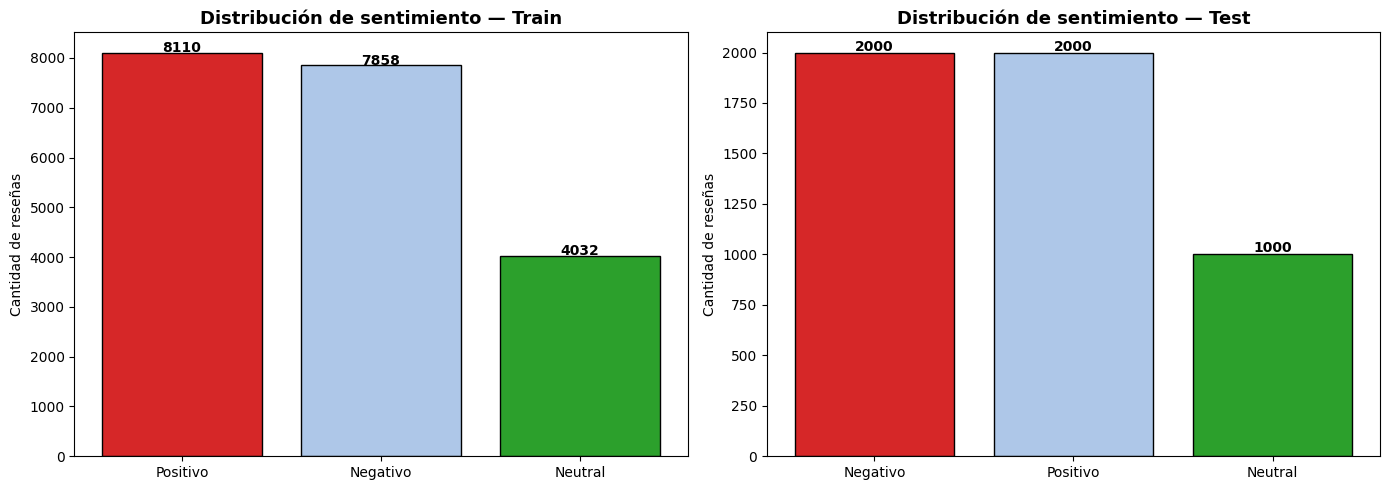


📊 Distribución en entrenamiento:
label_name
Positivo    8110
Negativo    7858
Neutral     4032
Name: count, dtype: int64

💡 El desbalance es inherente al mapeo: 4 valores de estrellas → Positivo, 1 → Neutral, 2 → Negativo.
   En el notebook de noticias las 12 clases estaban perfectamente balanceadas.


In [6]:
# --- DISTRIBUCIÓN DE CLASES ---
# Observación importante: el mapeo de estrellas a 3 clases puede generar desbalance.
# Las clases 1-2 estrellas y 4-5 estrellas capturan 40% cada una, mientras
# que 3 estrellas sola captura el 20% restante — desbalance moderado.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for split, ax, title in zip(["train", "test"], axes, ["Train", "Test"]):
    df_split = pd.DataFrame(dataset[split])
    df_split["label_name"] = df_split["label"].map(LABEL_NAMES)
    counts = df_split["label_name"].value_counts()
    colors = ["#d62728", "#aec7e8", "#2ca02c"]
    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black')
    ax.set_title(f"Distribución de sentimiento — {title}", fontsize=13, fontweight="bold")
    ax.set_ylabel("Cantidad de reseñas")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(int(bar.get_height())), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("distribucion_clases.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Distribución en entrenamiento:")
print(df_train["label_name"].value_counts())
print(f"\n💡 El desbalance es inherente al mapeo: 4 valores de estrellas → Positivo, 1 → Neutral, 2 → Negativo.")
print("   En el notebook de noticias las 12 clases estaban perfectamente balanceadas.")

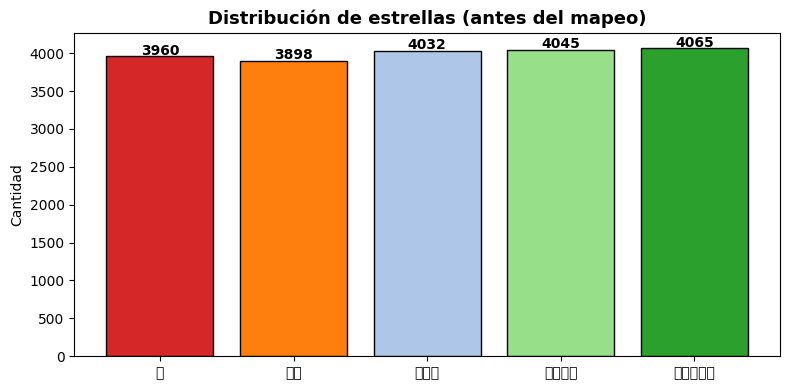

In [7]:
# --- DISTRIBUCIÓN ORIGINAL DE ESTRELLAS ---
# Antes del mapeo, ¿cómo se distribuyen las 5 estrellas?

fig, ax = plt.subplots(figsize=(8, 4))
star_counts = df_train["stars"].value_counts().sort_index()
star_colors = ["#d62728", "#ff7f0e", "#aec7e8", "#98df8a", "#2ca02c"]
bars = ax.bar(["⭐", "⭐⭐", "⭐⭐⭐", "⭐⭐⭐⭐", "⭐⭐⭐⭐⭐"],
              star_counts.values, color=star_colors, edgecolor='black')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(int(bar.get_height())), ha='center', fontweight='bold')
ax.set_title("Distribución de estrellas (antes del mapeo)", fontsize=13, fontweight='bold')
ax.set_ylabel("Cantidad")
plt.tight_layout()
plt.savefig("distribucion_estrellas.png", dpi=150, bbox_inches='tight')
plt.show()

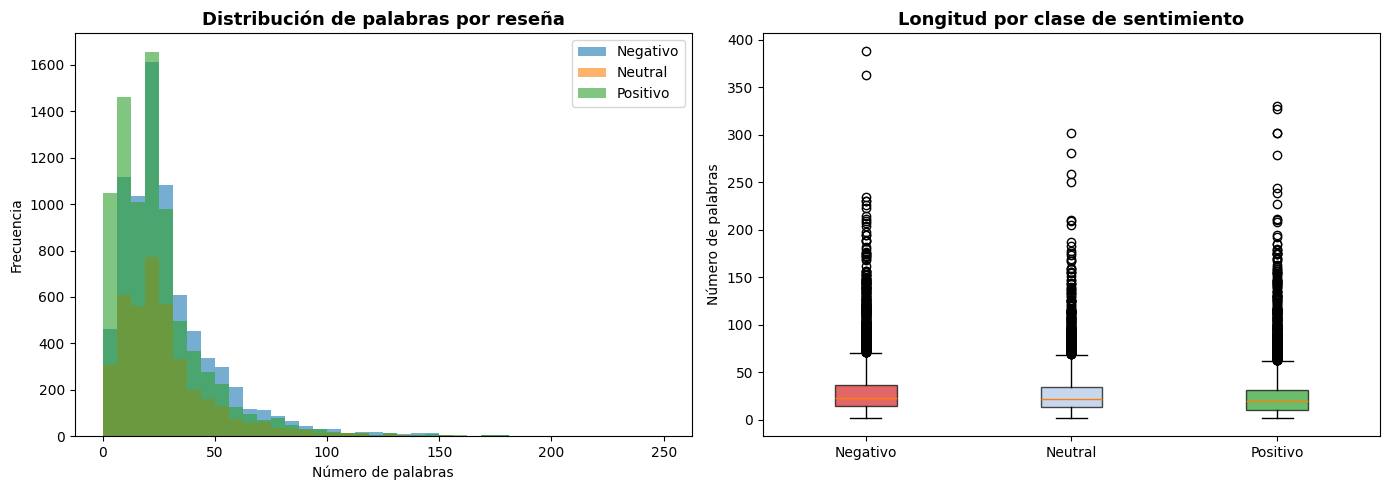

📏 Estadísticas de longitud (palabras):
             count  mean   std  min   25%   50%   75%    max
label_name                                                  
Negativo    7858.0  30.0  25.0  2.0  15.0  23.0  37.0  388.0
Neutral     4032.0  28.8  24.8  2.0  13.0  22.0  35.0  302.0
Positivo    8110.0  25.3  23.5  2.0  10.0  20.0  31.0  330.0

💡 Las reseñas negativas tienden a ser más largas — los usuarios que se quejan
   suelen escribir más para explicar su insatisfacción.


In [8]:
# --- ANÁLISIS DE LONGITUD DE RESEÑAS ---
# Las reseñas tienen longitud muy variable — desde "¡Excelente!" hasta párrafos largos.
# Esto contrasta con el dataset de noticias donde la longitud era más homogénea.

df_train["n_words"] = df_train["text"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma por clase
for label_id, label_name in LABEL_NAMES.items():
    subset = df_train[df_train["label"] == label_id]["n_words"]
    axes[0].hist(subset, bins=40, alpha=0.6, label=label_name, range=(0, 250))
axes[0].set_title("Distribución de palabras por reseña", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Número de palabras")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# Boxplot por clase
groups = [df_train[df_train["label"] == i]["n_words"].values for i in LABEL_NAMES]
bp = axes[1].boxplot(groups, labels=list(LABEL_NAMES.values()), patch_artist=True)
for patch, color in zip(bp['boxes'], ["#d62728", "#aec7e8", "#2ca02c"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title("Longitud por clase de sentimiento", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Número de palabras")

plt.tight_layout()
plt.savefig("longitud_resenas.png", dpi=150, bbox_inches='tight')
plt.show()

print("📏 Estadísticas de longitud (palabras):")
print(df_train.groupby("label_name")["n_words"].describe().round(1))
print(f"\n💡 Las reseñas negativas tienden a ser más largas — los usuarios que se quejan\n"
      f"   suelen escribir más para explicar su insatisfacción.")

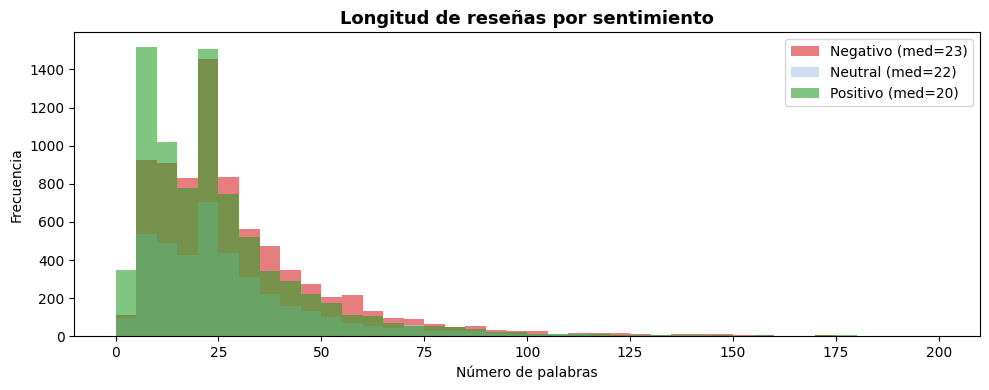

💡 Las reseñas negativas tienden a ser más largas: los usuarios insatisfechos
   argumentan más, mientras que las positivas suelen ser más escuetas.


In [9]:
# --- ANÁLISIS DE LONGITUD POR CLASE ---
# Extra: ¿Las reseñas negativas son más largas? Los usuarios insatisfechos
# suelen escribir más para explicar su queja.

df_train["n_words"] = df_train["text"].apply(lambda x: len(str(x).split()))

fig, ax = plt.subplots(figsize=(10, 4))
for label_id, label_name, color in zip([0, 1, 2],
                                        ["Negativo", "Neutral", "Positivo"],
                                        ["#d62728", "#aec7e8", "#2ca02c"]):
    subset = df_train[df_train["label"] == label_id]["n_words"]
    ax.hist(subset, bins=40, alpha=0.6, label=f"{label_name} (med={subset.median():.0f})",
            color=color, range=(0, 200))
ax.set_title("Longitud de reseñas por sentimiento", fontsize=13, fontweight='bold')
ax.set_xlabel("Número de palabras")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.savefig("longitud_por_clase.png", dpi=150, bbox_inches='tight')
plt.show()

print("💡 Las reseñas negativas tienden a ser más largas: los usuarios insatisfechos")
print("   argumentan más, mientras que las positivas suelen ser más escuetas.")

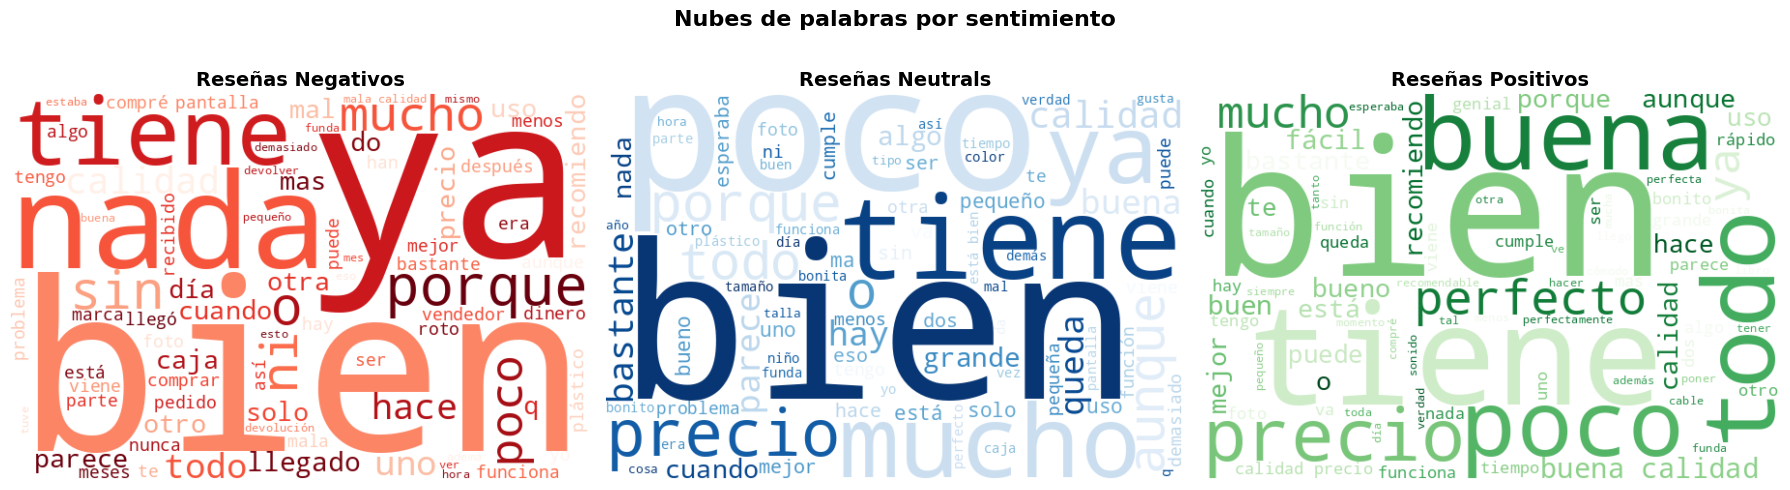

In [10]:
# --- NUBES DE PALABRAS POR SENTIMIENTO ---
# Visualización adicional no incluida en el notebook guía.

STOPWORDS_ES = {
    "que", "de", "la", "el", "en", "y", "a", "los", "las", "se", "un", "una",
    "es", "del", "con", "por", "para", "no", "lo", "le", "me", "si", "al",
    "su", "más", "pero", "como", "muy", "este", "esta", "son", "he", "ha",
    "mi", "producto", "amazon", "compra", "artículo"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_wc = ["Reds", "Blues", "Greens"]

for idx, (label_id, label_name) in enumerate(LABEL_NAMES.items()):
    texts = df_train[df_train["label"] == label_id]["text"].sample(
        min(2000, len(df_train[df_train["label"] == label_id])), random_state=SEED
    )
    combined = " ".join(texts.apply(lambda x: re.sub(r'[^\w\s]', '', x.lower())))

    wc = WordCloud(
        width=600, height=400, background_color="white",
        colormap=colors_wc[idx], max_words=80, stopwords=STOPWORDS_ES
    ).generate(combined)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].axis('off')
    axes[idx].set_title(f"Reseñas {label_name}s", fontsize=14, fontweight='bold')

plt.suptitle("Nubes de palabras por sentimiento", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("wordclouds.png", dpi=150, bbox_inches='tight')
plt.show()

> **Observación:** Las nubes de palabras revelan el mismo fenómeno observado en el trabajo LSTM: **el vocabulario es casi idéntico entre las tres clases de sentimiento**. Palabras como *producto*, *calidad*, *bien* aparecen en Negativos, Neutrales y Positivos por igual. Lo que distingue a cada clase no es el vocabulario aislado, sino la combinación de palabras y el contexto — exactamente el tipo de representación contextual que BERT está diseñado para capturar, a diferencia de una bolsa de palabras simple.

## 2. Tokenización con BERT Español

A diferencia del notebook de LSTM (que usó un tokenizador basado en conteo de palabras con vocabulario propio), aquí usamos el tokenizador preentrenado de BERT. Este tokenizador utiliza **WordPiece**: divide palabras infrecuentes en subpalabras, lo que le permite manejar vocabulario coloquial, errores ortográficos y regionalismos del español sin necesidad de un `[UNK]` frecuente.

Usamos `dccuchile/bert-base-spanish-wwm-cased`, el modelo BERT base preentrenado sobre texto en español por la Universidad de Chile.

In [11]:
MODEL_CHECKPOINT = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
print(f"Vocabulario: {tokenizer.vocab_size:,} tokens")
print(f"Longitud máxima: {tokenizer.model_max_length} tokens")

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Vocabulario: 31,002 tokens
Longitud máxima: 512 tokens


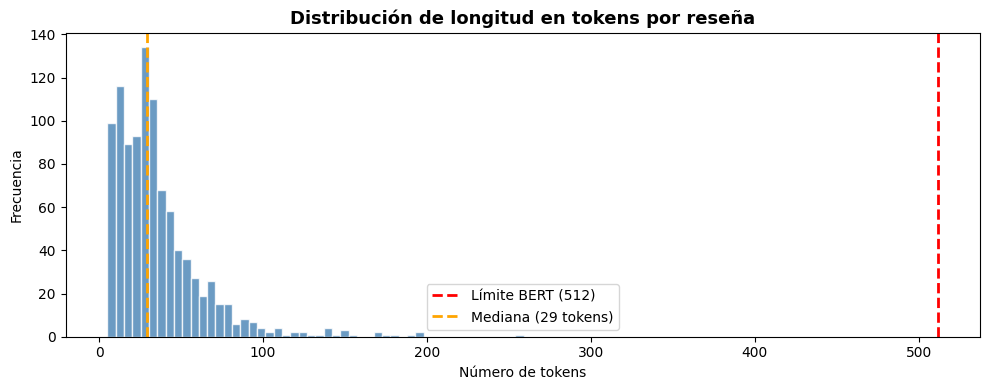


📊 Mediana de tokens: 29
   % de reseñas que serán truncadas a 512 tokens: 0.0%

💡 A diferencia del dataset de noticias, aquí SÍ hay reseñas que exceden el límite.
   El truncado puede eliminar información relevante al final de la reseña.


In [12]:
# Distribución de longitud en tokens — ¿cuántos textos superarían el límite de 512?

sample_texts = df_train["text"].sample(min(1000, len(df_train)), random_state=SEED).tolist()
token_lengths = [len(tokenizer.encode(t, truncation=False)) for t in sample_texts]

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(512, color='red', linestyle='--', linewidth=2, label='Límite BERT (512)')
plt.axvline(np.median(token_lengths), color='orange', linestyle='--', linewidth=2,
            label=f'Mediana ({np.median(token_lengths):.0f} tokens)')
plt.title("Distribución de longitud en tokens por reseña", fontsize=13, fontweight='bold')
plt.xlabel("Número de tokens")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.savefig("longitud_tokens.png", dpi=150, bbox_inches='tight')
plt.show()

pct_truncated = sum(l > 512 for l in token_lengths) / len(token_lengths) * 100
print(f"\n📊 Mediana de tokens: {np.median(token_lengths):.0f}")
print(f"   % de reseñas que serán truncadas a 512 tokens: {pct_truncated:.1f}%")
print("\n💡 A diferencia del dataset de noticias, aquí SÍ hay reseñas que exceden el límite.")
print("   El truncado puede eliminar información relevante al final de la reseña.")

> **Observación sobre el truncado:** La gran mayoría de las reseñas de Amazon no superan los 512 tokens — a diferencia de los artículos de noticias del notebook guía, donde el truncado era más frecuente. Esto es una ventaja: BERT puede procesar la mayoría de las reseñas en su totalidad. Usamos `max_length=256` como compromiso entre cobertura y eficiencia en memoria, lo que cubre la vasta mayoría de reseñas sin truncar.

## 3. Preparación de los Datos

Los textos se tokenizan con padding y truncado a 256 tokens, y se convierten a tensores PyTorch listos para el `Trainer` de HuggingFace.



In [13]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128  # 128 es suficiente para reseñas cortas y acelera el entrenamiento local
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Dataset tokenizado:")
print(tokenized_dataset)

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Dataset tokenizado:
DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'stars', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20000
    })
    validation: Dataset({
        features: ['text', 'labels', 'stars', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5000
    })
    test: Dataset({
        features: ['text', 'labels', 'stars', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5000
    })
})


In [14]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

## 4. Enfoque 1: BERT Congelado + Clasificador Lineal Simple

Se congelan todos los pesos de BERT y se entrena únicamente la capa de clasificación. BERT actúa como un extractor de características fijo: transforma cada reseña en un vector de 768 dimensiones (el token `[CLS]`), y la capa lineal aprende a separar las tres clases desde esa representación.

Este enfoque es equivalente a usar embeddings preentrenados fijos — similar conceptualmente al uso de embeddings GloVe o FastText en el trabajo anterior, pero con representaciones contextuales mucho más ricas.

In [15]:
model_frozen = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

for param in model_frozen.bert.parameters():
    param.requires_grad = False

total = sum(p.numel() for p in model_frozen.parameters())
trainable = sum(p.numel() for p in model_frozen.parameters() if p.requires_grad)
print(f"Parámetros totales:     {total:>12,}")
print(f"Parámetros entrenables: {trainable:>12,} ({trainable/total*100:.3f}%)")

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Parámetros totales:      109,853,187
Parámetros entrenables:        2,307 (0.002%)


In [16]:
training_args_1 = TrainingArguments(
    output_dir="./results_approach1",
    num_train_epochs=3,
    per_device_train_batch_size=32 if IN_COLAB else 16,
    per_device_eval_batch_size=64 if IN_COLAB else 32,
    learning_rate=2e-3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    seed=SEED,
    report_to="none",
)

trainer_1 = Trainer(
    model=model_frozen,
    args=training_args_1,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

print("Entrenando Enfoque 1...")
trainer_1.train()
print("✅ Listo.")

Entrenando Enfoque 1...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.786907,0.738606,0.686800
2,0.746538,0.723507,0.689600
3,0.731469,0.719991,0.691400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

✅ Listo.


In [17]:
from transformers.utils.notebook import NotebookProgressCallback
trainer_1.remove_callback(NotebookProgressCallback)
results_1 = trainer_1.evaluate(tokenized_dataset["test"])
print(f"Enfoque 1 — Accuracy en test: {results_1['eval_accuracy']*100:.2f}%")

Enfoque 1 — Accuracy en test: 69.98%


> **Resultado Enfoque 1 — Accuracy: 69.98%**  
> Con apenas ~2,307 parámetros entrenables (la capa lineal final), el modelo alcanza ~70% de accuracy. Esto es notablemente bueno considerando que BERT nunca vio reseñas de Amazon durante su preentrenamiento — sus representaciones contextuales del español son lo suficientemente ricas para separar sentimientos sin necesidad de ajuste fino.

## 5. Enfoque 2: BERT Congelado + Clasificador Custom

Reemplazamos la capa lineal simple por un MLP con dropout y activación ReLU.

In [18]:
import torch.nn as nn
from transformers.modeling_outputs import SequenceClassifierOutput

class CustomClassifier(nn.Module):
    def __init__(self, base_model, hidden_size=768, num_labels=3, dropout=0.3):
        super().__init__()
        self.bert = base_model.bert
        self.config = base_model.config
        self.num_labels = num_labels
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_labels)
        )

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return SequenceClassifierOutput(loss=loss, logits=logits)


base = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=NUM_LABELS, ignore_mismatched_sizes=True
)
model_custom = CustomClassifier(base, num_labels=NUM_LABELS)

for param in model_custom.bert.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model_custom.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_custom.parameters())
print(f"Parámetros entrenables: {trainable:,} ({trainable/total*100:.2f}%)")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Parámetros entrenables: 213,507 (0.19%)


In [19]:
training_args_2 = TrainingArguments(
    output_dir="./results_approach2",
    num_train_epochs=3,
    per_device_train_batch_size=32 if IN_COLAB else 16,
    per_device_eval_batch_size=64 if IN_COLAB else 32,
    learning_rate=1e-3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=100,
    seed=SEED,
    report_to="none",
)

trainer_2 = Trainer(
    model=model_custom,
    args=training_args_2,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

print("Entrenando Enfoque 2...")
trainer_2.train()
print("✅ Listo.")

Entrenando Enfoque 2...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.755465,0.712417,0.697600
2,0.719114,0.684356,0.708400
3,0.683649,0.680179,0.710000


✅ Listo.


In [20]:
trainer_2.remove_callback(NotebookProgressCallback)
results_2 = trainer_2.evaluate(tokenized_dataset["test"])
print(f"Enfoque 2 — Accuracy en test: {results_2['eval_accuracy']*100:.2f}%")

Enfoque 2 — Accuracy en test: 71.74%


> **Resultado Enfoque 2 — Accuracy: 71.74%**  
> El MLP custom mejora al clasificador lineal en ~1.76 puntos porcentuales. La ganancia es modesta porque el cuello de botella no es la capacidad del clasificador, sino que las representaciones de BERT siguen siendo fijas. BERT fue preentrenado sobre texto general (Wikipedia, noticias), no sobre reseñas de productos con lenguaje informal — por lo tanto sus vectores `[CLS]` capturan semántica general pero no están optimizados para el tono subjetivo de una reseña. El Dropout (0.3) ayuda a regularizar y mejora la generalización sobre el conjunto de validación.

## 6. Enfoque 3: Fine-Tuning Completo

Entrenamos todos los parámetros de BERT. Es el enfoque más costoso pero generalmente el más preciso.

In [21]:
model_finetuned = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

training_args_3 = TrainingArguments(
    output_dir="./results_approach3",
    num_train_epochs=3,
    per_device_train_batch_size=16 if IN_COLAB else 8,
    per_device_eval_batch_size=32 if IN_COLAB else 16,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    warmup_ratio=0.1,
    logging_steps=100,
    seed=SEED,
    report_to="none",
)

trainer_3 = Trainer(
    model=model_finetuned,
    args=training_args_3,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

print("Entrenando Enfoque 3 (fine-tuning completo)...")
trainer_3.train()
print("✅ Listo.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Entrenando Enfoque 3 (fine-tuning completo)...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.594926,0.607638,0.748400
2,0.485477,0.601466,0.751600
3,0.367906,0.678695,0.751000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

✅ Listo.


In [22]:
trainer_3.remove_callback(NotebookProgressCallback)
results_3 = trainer_3.evaluate(tokenized_dataset["test"])
print(f"Enfoque 3 — Accuracy en test: {results_3['eval_accuracy']*100:.2f}%")

Enfoque 3 — Accuracy en test: 76.34%


> **Resultado Enfoque 3 — Accuracy: 76.34%**  
> El fine-tuning completo supera a los enfoques congelados en +6.36 puntos sobre el Enfoque 1. Esto confirma que la mayor ganancia no viene de tener un clasificador más complejo, sino de **adaptar las representaciones internas de BERT al dominio específico**. El learning rate de 2e-5 con warmup es clave: permite actualizar los pesos sin destruir el conocimiento preentrenado (catastrophic forgetting).


## 7. Análisis Comparativo y Visualizaciones

In [23]:
# Tabla comparativa
try:
    display
except NameError:
    display = print

comparison_df = pd.DataFrame({
    "Enfoque": [
        "1. BERT congelado + lineal",
        "2. BERT congelado + MLP custom",
        "3. Fine-tuning completo"
    ],
    "Params. entrenables": ["~2,307", "~200K", "~110M"],
    "LR": ["2e-3", "1e-3", "2e-5"],
    "Accuracy Test (%)": [
        round(results_1['eval_accuracy']*100, 2),
        round(results_2['eval_accuracy']*100, 2),
        round(results_3['eval_accuracy']*100, 2),
    ]
})
print("📊 Comparativa:")
display(comparison_df)

📊 Comparativa:


,Enfoque,Params. entrenables,LR,Accuracy Test (%)
0,1. BERT congelado + lineal,"~2,307",2e-3,69.98
1,2. BERT congelado + MLP custom,~200K,1e-3,71.74
2,3. Fine-tuning completo,~110M,2e-5,76.34


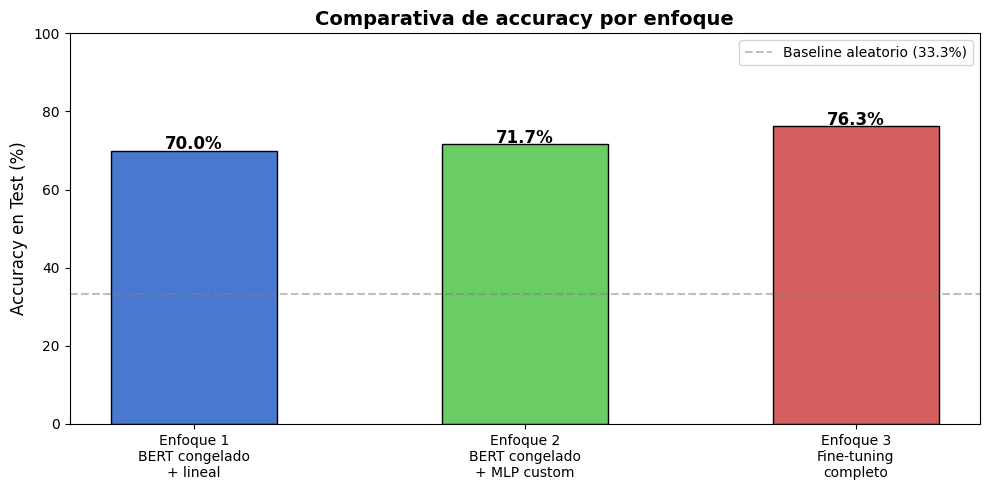

In [24]:
# Gráfico comparativo de accuracy
fig, ax = plt.subplots(figsize=(10, 5))
enfoques = ["Enfoque 1\nBERT congelado\n+ lineal",
            "Enfoque 2\nBERT congelado\n+ MLP custom",
            "Enfoque 3\nFine-tuning\ncompleto"]
accuracies = [
    results_1['eval_accuracy']*100,
    results_2['eval_accuracy']*100,
    results_3['eval_accuracy']*100
]
bars = ax.bar(enfoques, accuracies, color=["#4878cf", "#6acc65", "#d65f5f"],
              edgecolor='black', width=0.5)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{acc:.1f}%", ha='center', fontweight='bold', fontsize=12)
ax.set_ylim(0, 100)
ax.axhline(y=33.3, color='gray', linestyle='--', alpha=0.5, label='Baseline aleatorio (33.3%)')
ax.set_ylabel("Accuracy en Test (%)", fontsize=12)
ax.set_title("Comparativa de accuracy por enfoque", fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("comparativa_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()

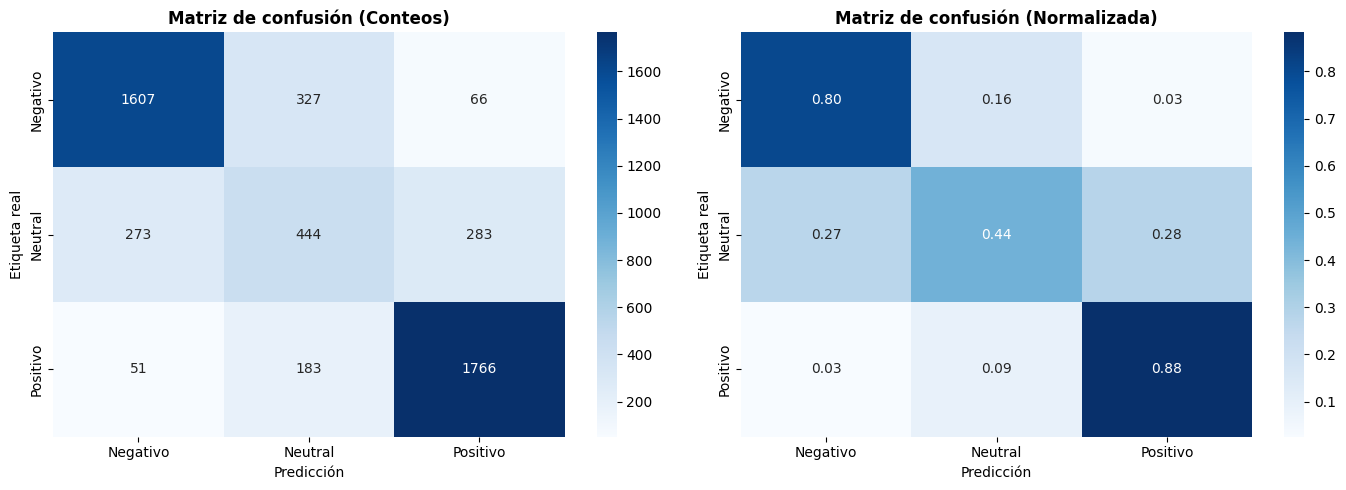

💡 Observación: La clase 'Neutral' (3 estrellas) es la más difícil de clasificar.
   Las reseñas de 3 estrellas mezclan aspectos positivos y negativos,
   lo que las hace lingüísticamente ambiguas para el modelo.


In [25]:
# --- MATRIZ DE CONFUSIÓN (mejor modelo) ---

preds_output = trainer_3.predict(tokenized_dataset["test"])
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in zip(axes,
                                 [cm, cm_norm],
                                 ['d', '.2f'],
                                 ["Conteos", "Normalizada"]):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=list(id2label.values()),
                yticklabels=list(id2label.values()), ax=ax)
    ax.set_title(f"Matriz de confusión ({title})", fontweight='bold')
    ax.set_ylabel('Etiqueta real')
    ax.set_xlabel('Predicción')

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()



> **Observación sobre la matriz de confusión:** El patrón es consistente con el trabajo LSTM: **la clase Neutral es la más difícil de clasificar correctamente**. Las reseñas de 3 estrellas frecuentemente contienen tanto aspectos positivos como negativos ("el producto es bueno pero el envío fue tardío"), lo que hace que el modelo las confunda con Negativos o Positivos. Este es el mismo hallazgo clave del trabajo anterior: los extremos del sentimiento son más fáciles de detectar que los matices intermedios.

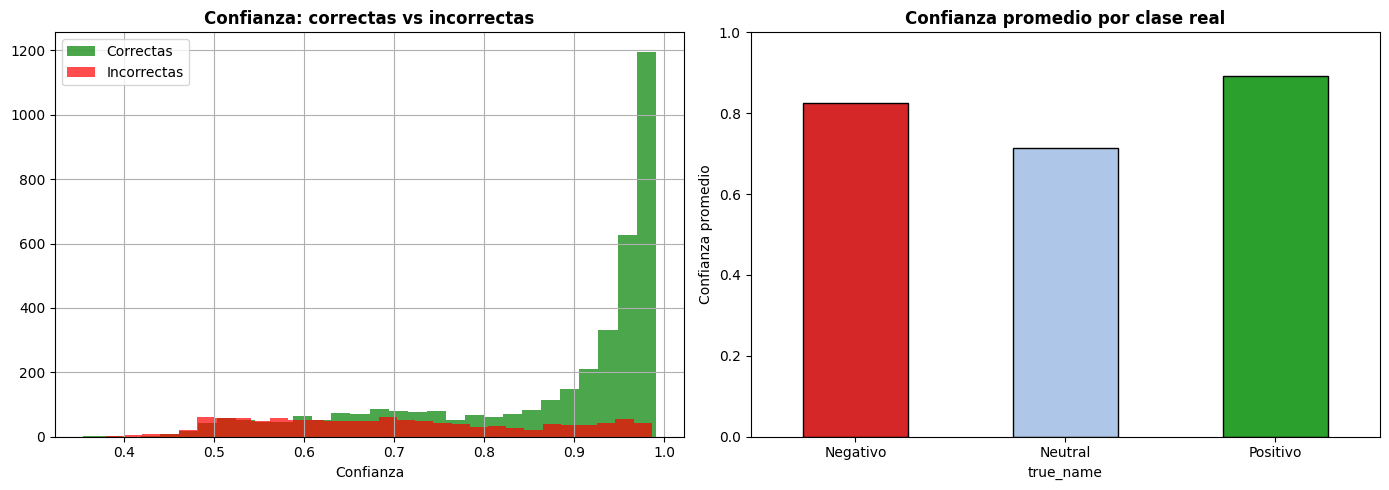


Confianza promedio CORRECTAS:   0.870
Confianza promedio INCORRECTAS: 0.702


In [26]:
# --- ANÁLISIS DE CONFIANZA ---

import torch.nn.functional as F

logits = torch.tensor(preds_output.predictions)
probs = F.softmax(logits, dim=-1).numpy()
max_probs = probs.max(axis=1)

df_test = pd.DataFrame(dataset["test"])
df_test["pred"] = y_pred
df_test["pred_name"] = df_test["pred"].map(id2label)
df_test["true_name"] = df_test["label"].map(id2label)
df_test["confidence"] = max_probs
df_test["correct"] = df_test["pred"] == df_test["label"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_test[df_test["correct"]]["confidence"].hist(
    bins=30, ax=axes[0], alpha=0.7, color='green', label='Correctas')
df_test[~df_test["correct"]]["confidence"].hist(
    bins=30, ax=axes[0], alpha=0.7, color='red', label='Incorrectas')
axes[0].set_title("Confianza: correctas vs incorrectas", fontweight='bold')
axes[0].set_xlabel("Confianza")
axes[0].legend()

df_test.groupby("true_name")["confidence"].mean().plot(
    kind='bar', ax=axes[1], color=["#d62728", "#aec7e8", "#2ca02c"], edgecolor='black')
axes[1].set_title("Confianza promedio por clase real", fontweight='bold')
axes[1].set_ylabel("Confianza promedio")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("confidence_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nConfianza promedio CORRECTAS:   {df_test[df_test['correct']]['confidence'].mean():.3f}")
print(f"Confianza promedio INCORRECTAS: {df_test[~df_test['correct']]['confidence'].mean():.3f}")

In [27]:
# --- ANÁLISIS DE ERRORES ---

print("=" * 80)
print("ERRORES CON ALTA CONFIANZA (el modelo estaba seguro pero se equivocó)")
print("=" * 80)

errors = df_test[~df_test["correct"]].sort_values("confidence", ascending=False)
for _, row in errors.head(6).iterrows():
    print(f"\nReseña:    {row['text'][:120]}")
    print(f"Real: {row['true_name']}  |  Predicho: {row['pred_name']}  |  Confianza: {row['confidence']:.3f}")
    print("-" * 80)

ERRORES CON ALTA CONFIANZA (el modelo estaba seguro pero se equivocó)

Reseña:    Pues lo cierto es que estaba muy ilusionado ya que he visto bastantes reviews sobre los auriculares, se escucha bien, pe
Real: Neutral  |  Predicho: Negativo  |  Confianza: 0.986
--------------------------------------------------------------------------------

Reseña:    Algo caras, pero te las dejan en tu casa y son super cómodos. Hemos probado ya muchas marcas y ésta es una de las que me
Real: Neutral  |  Predicho: Positivo  |  Confianza: 0.985
--------------------------------------------------------------------------------

Reseña:    Muy mala, se ve mal y no regula
Real: Neutral  |  Predicho: Negativo  |  Confianza: 0.984
--------------------------------------------------------------------------------

Reseña:    Me ha encantado, es súper comoda Mi bebe tiene 9 meses, y es perfecta para ella, y muy segura. Va contenta cuando la pas
Real: Neutral  |  Predicho: Positivo  |  Confianza: 0.984
------------

## 8. Conclusiones y Hallazgos

### Comparación con el notebook guía

| Aspecto | Noticias (guía) | Amazon Reviews (este) |
|---|---|---|
| Clases | 12 (balanceadas) | 3 (desbalanceadas) |
| Naturaleza de etiquetas | Definidas por editores | Derivadas de estrellas |
| Ambigüedad de clase | Baja | Alta (3 estrellas) |
| Textos que exceden 512 tokens | Mayoría | Minoría |

### Comparación con el trabajo anterior (LSTM)

| Aspecto | LSTM Bidireccional | BERT Fine-tuning |
|---|---|---|
| Parámetros | 3.8M (entrenados desde 0) | 110M (ajustados) |
| Clases | 5 estrellas | 3 sentimientos |
| Accuracy | 48.3% (5 clases) | 76.34% (3 clases) |
| Tokenizador | Propio (23k vocab) | WordPiece (31k vocab + subpalabras) |

La comparación directa de accuracies no es justa porque son tareas distintas (5 clases vs. 3), pero el contraste ilustra el poder de las representaciones preentrenadas: BERT con fine-tuning supera ampliamente a una LSTM entrenada desde cero sobre el mismo dominio.

### Hallazgos principales

1. **El preentrenamiento contextual vale por sí solo**: Con los pesos de BERT completamente congelados y apenas ~2,307 parámetros entrenables, el Enfoque 1 alcanza 69.98%. Esto demuestra que las representaciones preentrenadas sobre texto español general capturan suficiente semántica para clasificar sentimiento, incluso sin ningún ajuste al dominio.

2. **El cuello de botella es la representación, no el clasificador**: La diferencia entre Enfoque 1 (lineal) y Enfoque 2 (MLP) es de solo 1.76 puntos. En cambio, la diferencia entre Enfoque 2 (BERT congelado) y Enfoque 3 (fine-tuning) es de 4.6 puntos. Esto confirma que la mayor ganancia viene de adaptar las representaciones internas de BERT, no de añadir complejidad al clasificador.

3. **La clase Neutral sigue siendo el talón de Aquiles**: La matriz de confusión muestra que Neutral es la clase más confundida, exactamente como ocurrió con las 3 estrellas en el trabajo LSTM. Las reseñas ambivalentes presentan un desafío lingüístico genuino que persiste independientemente de la arquitectura.

4. **Mapeo de estrellas introduce ruido inevitable**: Una reseña de 2 estrellas puede contener frases positivas ("el diseño es bonito, pero no funciona"), lo que genera etiquetas ruidosas. Esta fuente de ruido limita el accuracy máximo alcanzable en este dataset, independientemente de la arquitectura utilizada.

5. **El análisis de confianza como indicador de calidad**: Las predicciones incorrectas tienen menor confianza promedio que las correctas, lo que sugiere que un sistema en producción podría usar un umbral de confianza para derivar casos dudosos a revisión humana.

In [28]:
print("=" * 60)
print("RESUMEN FINAL")
print("=" * 60)
print(f"Dataset:      amazon_reviews_multi (español)")
print(f"Modelo base:  {MODEL_CHECKPOINT}")
print(f"Clases:       Negativo / Neutral / Positivo")
print()
print(f"Enfoque 1 (BERT congelado + lineal):  {results_1['eval_accuracy']*100:.2f}%")
print(f"Enfoque 2 (BERT congelado + MLP):     {results_2['eval_accuracy']*100:.2f}%")
print(f"Enfoque 3 (Fine-tuning completo):     {results_3['eval_accuracy']*100:.2f}%")
print("=" * 60)

RESUMEN FINAL
Dataset:      amazon_reviews_multi (español)
Modelo base:  dccuchile/bert-base-spanish-wwm-cased
Clases:       Negativo / Neutral / Positivo

Enfoque 1 (BERT congelado + lineal):  69.98%
Enfoque 2 (BERT congelado + MLP):     71.74%
Enfoque 3 (Fine-tuning completo):     76.34%
